# Active Inference: Temperature Control with Action Selection

This notebook extends `01_temp_control_inference_only` by adding **actions**.
The agent can now select a heating/cooling action each step to drive the room
toward its preferred (comfortable) temperature.

## What's new vs notebook 01

| | Notebook 01 | This notebook |
|---|---|---|
| B matrix | 1 action (autonomous) | 3 actions: cool / do-nothing / heat |
| Policy selection | none | 1-step-ahead EFE |
| Agent loop | `infer_states` only | `infer_states` → `infer_policies` → `sample_action` |

### Key matrices
| Matrix | Meaning |
|--------|---------|
| `A` | Likelihood: `P(observation \| state)` — same as before |
| `B` | Transition: `P(next_state \| state, action)` — now action-dependent |
| `C` | Log preferences over observations — drives action toward comfortable |
| `D` | Prior over initial states |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pymdp.legacy import utils
from pymdp.legacy.agent import Agent

## 1. Define the Generative Model

In [2]:
# States: 0=very_cold, 1=cold, 2=comfortable, 3=warm, 4=hot
# Observations: 3 coarse readings (same partial observability as notebook 01)
# Actions: 0=cool, 1=do_nothing, 2=heat

num_states  = [5]
num_obs     = [3]
num_actions = [3]   # <-- NEW: 3 control actions

STATE_LABELS  = ["very_cold", "cold", "comfortable", "warm", "hot"]
OBS_LABELS    = ["obs:cold", "obs:comfortable", "obs:hot"]
ACTION_LABELS = ["cool", "do_nothing", "heat"]

In [3]:
# --- A matrix: likelihood P(obs | state) — unchanged from notebook 01 ---
A = utils.initialize_empty_A(num_obs, num_states)
A[0] = np.array([
    #   vc    co    cm    wa    ho
    [0.80, 0.60, 0.10, 0.05, 0.00],  # obs=cold
    [0.15, 0.30, 0.70, 0.30, 0.15],  # obs=comfortable
    [0.05, 0.10, 0.20, 0.65, 0.85],  # obs=hot
])
assert np.allclose(A[0].sum(axis=0), 1.0)
print("A matrix:")
print(np.round(A[0], 2))

A matrix:
[[0.8  0.6  0.1  0.05 0.  ]
 [0.15 0.3  0.7  0.3  0.15]
 [0.05 0.1  0.2  0.65 0.85]]


In [4]:
# --- B matrix: P(s' | s, action), shape (5 states x 5 states x 3 actions) ---
#
# action=0 (cool):       shifts distribution one step toward colder
# action=1 (do_nothing): autonomous drift — same as notebook 01
# action=2 (heat):       shifts distribution one step toward hotter

B = utils.initialize_empty_B(num_states, num_actions)

# action=1 do_nothing: autonomous mean-reverting dynamics (identical to notebook 01)
B[0][:, :, 1] = np.array([
    [0.75, 0.20, 0.05, 0.00, 0.00],
    [0.20, 0.60, 0.15, 0.05, 0.00],
    [0.05, 0.15, 0.60, 0.15, 0.05],
    [0.00, 0.05, 0.15, 0.60, 0.20],
    [0.00, 0.00, 0.05, 0.20, 0.75],
])

# action=0 cool: nudge probability mass one step toward colder states
B[0][:, :, 0] = np.array([
    [0.85, 0.40, 0.10, 0.02, 0.00],
    [0.12, 0.50, 0.30, 0.08, 0.02],
    [0.02, 0.08, 0.45, 0.30, 0.08],
    [0.01, 0.02, 0.12, 0.50, 0.35],
    [0.00, 0.00, 0.03, 0.10, 0.55],
])

# action=2 heat: nudge probability mass one step toward hotter states
B[0][:, :, 2] = np.array([
    [0.55, 0.10, 0.03, 0.00, 0.00],
    [0.35, 0.50, 0.12, 0.02, 0.01],
    [0.08, 0.30, 0.45, 0.08, 0.02],
    [0.02, 0.08, 0.30, 0.50, 0.12],
    [0.00, 0.02, 0.10, 0.40, 0.85],
])

for a in range(3):
    assert np.allclose(B[0][:, :, a].sum(axis=0), 1.0), f"B[:,:,{a}] cols must sum to 1"

print("B matrices verified.")
for i, label in enumerate(ACTION_LABELS):
    print(f"\nB[:,:,{i}] ({label}):")
    print(np.round(B[0][:, :, i], 2))

B matrices verified.

B[:,:,0] (cool):
[[0.85 0.4  0.1  0.02 0.  ]
 [0.12 0.5  0.3  0.08 0.02]
 [0.02 0.08 0.45 0.3  0.08]
 [0.01 0.02 0.12 0.5  0.35]
 [0.   0.   0.03 0.1  0.55]]

B[:,:,1] (do_nothing):
[[0.75 0.2  0.05 0.   0.  ]
 [0.2  0.6  0.15 0.05 0.  ]
 [0.05 0.15 0.6  0.15 0.05]
 [0.   0.05 0.15 0.6  0.2 ]
 [0.   0.   0.05 0.2  0.75]]

B[:,:,2] (heat):
[[0.55 0.1  0.03 0.   0.  ]
 [0.35 0.5  0.12 0.02 0.01]
 [0.08 0.3  0.45 0.08 0.02]
 [0.02 0.08 0.3  0.5  0.12]
 [0.   0.02 0.1  0.4  0.85]]


In [5]:
# --- C vector: log preferences — strong preference for obs:comfortable ---
C = utils.obj_array(1)
C[0] = np.array([-3.0, 5.0, -2.0])   # [cold, comfortable, hot]

# --- D vector: prior over initial states — start uncertain ---
D = utils.obj_array(1)
D[0] = utils.norm_dist(np.ones(5))

print("C (log preferences):", C[0])
print("D (initial prior):   ", np.round(D[0], 3))

C (log preferences): [-3.  5. -2.]
D (initial prior):    [0.2 0.2 0.2 0.2 0.2]


## 2. Instantiate the Agent

`policy_len=1` means the agent evaluates **one-step-ahead** Expected Free Energy (EFE)
for each action and picks the action that minimises it.
With only 3 possible actions, the policy space is tiny — each policy *is* a single action.

In [6]:
agent = Agent(
    A=A, B=B, C=C, D=D,
    inference_algo="VANILLA",
    policy_len=1,          # one-step-ahead policy evaluation
    inference_horizon=1,
    control_fac_idx=[0],   # state factor 0 is controllable
)
print("Agent created.")
print(f"Number of policies: {len(agent.policies)}")
print("Policies (each is one action index):")
for i, p in enumerate(agent.policies):
    print(f"  policy {i}: action={p[0,0]} ({ACTION_LABELS[p[0,0]]})")

Agent created.
Number of policies: 3
Policies (each is one action index):
  policy 0: action=0 (cool)
  policy 1: action=1 (do_nothing)
  policy 2: action=2 (heat)


## 3. Run a Simulation

In [7]:
def get_observation(true_state: int, A_matrix: np.ndarray) -> int:
    """Sample a noisy observation given the true hidden state."""
    return np.random.choice(A_matrix.shape[0], p=A_matrix[:, true_state])


def step_environment(true_state: int, action: int, B_matrix: np.ndarray) -> int:
    """Transition the environment given an action."""
    return np.random.choice(B_matrix.shape[0], p=B_matrix[:, true_state, action])


T = 40
true_state = 0   # start very_cold

history = {
    "true_state":  [],
    "observation": [],
    "action":      [],
    "efe":         [],   # EFE per policy at each step
}

np.random.seed(42)

for t in range(T):
    obs = get_observation(true_state, A[0])

    # --- perception: update belief over hidden states ---
    qs = agent.infer_states([obs])

    # --- action selection: evaluate 1-step EFE for each policy ---
    q_pi, efe = agent.infer_policies()

    # --- sample action from posterior over policies ---
    action = agent.sample_action()
    action_idx = int(action[0])

    history["true_state"].append(true_state)
    history["observation"].append(obs)
    history["action"].append(action_idx)
    history["efe"].append(efe.copy())

    true_state = step_environment(true_state, action_idx, B[0])

print("Simulation complete.")

Simulation complete.


## 4. Visualise Results

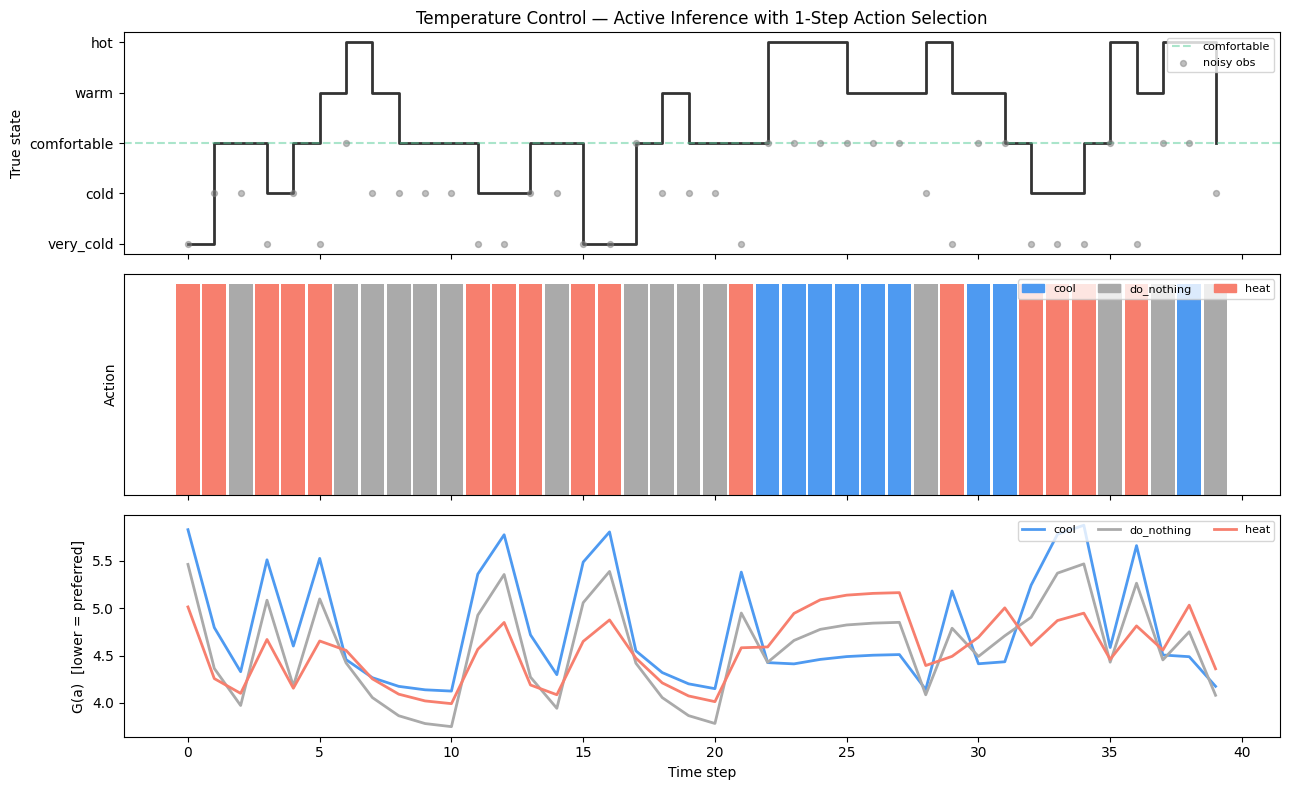

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
t_range = range(T)

action_colors = {0: "#4e9af1", 1: "#aaaaaa", 2: "#f77f6e"}  # cool=blue, none=grey, heat=red

# --- True state ---
axes[0].step(t_range, history["true_state"], where="post", linewidth=2, color="#333")
axes[0].set_yticks(range(5))
axes[0].set_yticklabels(STATE_LABELS)
axes[0].set_ylabel("True state")
axes[0].set_title("Temperature Control — Active Inference with 1-Step Action Selection")
axes[0].axhline(2, color="#57cc99", linestyle="--", alpha=0.5, label="comfortable")
axes[0].scatter(t_range, history["observation"], s=18, color="gray", alpha=0.5,
                zorder=3, label="noisy obs")
axes[0].legend(loc="upper right", fontsize=8)

# --- Actions taken ---
bar_colors = [action_colors[a] for a in history["action"]]
axes[1].bar(t_range, np.ones(T), color=bar_colors, width=0.9, align="center")
axes[1].set_yticks([])
axes[1].set_ylabel("Action")
from matplotlib.patches import Patch
legend_patches = [Patch(color=action_colors[i], label=ACTION_LABELS[i]) for i in range(3)]
axes[1].legend(handles=legend_patches, loc="upper right", fontsize=8, ncol=3)

# --- G(a): pymdp returns -G, so negate to get G ---
g_array = -np.array(history["efe"])   # shape (T, 3)
efe_colors = ["#4e9af1", "#aaaaaa", "#f77f6e"]
for i, (label, color) in enumerate(zip(ACTION_LABELS, efe_colors)):
    axes[2].plot(t_range, g_array[:, i], label=label, color=color, linewidth=2)
axes[2].set_ylabel("G(a)  [lower = preferred]")
axes[2].legend(loc="upper right", fontsize=8, ncol=3)
axes[2].axhline(0, color="gray", linestyle=":", alpha=0.4)
axes[2].set_xlabel("Time step")
margin = (g_array.max() - g_array.min()) * 0.05
axes[2].set_ylim(g_array.min() - margin, g_array.max() + margin)

plt.tight_layout()
plt.show()

## 5. Inspect EFE Values

In [9]:
# Show EFE values and chosen actions for the first 10 steps
print(f"{'t':>3}  {'EFE:cool':>10}  {'EFE:none':>10}  {'EFE:heat':>10}  {'chosen':>10}")
print("-" * 55)
for t in range(min(10, T)):
    efe_vals = history["efe"][t]
    chosen   = ACTION_LABELS[history["action"][t]]
    print(f"{t:>3}  {efe_vals[0]:>10.3f}  {efe_vals[1]:>10.3f}  {efe_vals[2]:>10.3f}  {chosen:>10}")

  t    EFE:cool    EFE:none    EFE:heat      chosen
-------------------------------------------------------
  0      -5.831      -5.464      -5.014        heat
  1      -4.796      -4.364      -4.257        heat
  2      -4.329      -3.972      -4.100  do_nothing
  3      -5.512      -5.085      -4.670        heat
  4      -4.601      -4.178      -4.155        heat
  5      -5.527      -5.099      -4.654        heat
  6      -4.457      -4.423      -4.555  do_nothing
  7      -4.266      -4.056      -4.254  do_nothing
  8      -4.174      -3.864      -4.092  do_nothing
  9      -4.138      -3.781      -4.020  do_nothing


## 6. Discussion

### What changed from notebook 01

The B matrix now has **3 action slices** instead of 1. The agent loop gains two new steps:

```
obs → infer_states (perception)
    → infer_policies (G per action)
    → sample_action  (pick action)
    → environment steps with that action
```

### Expected Free Energy (EFE) — 1-step decomposition

For each candidate action $a$, the agent computes:

$$G(a) = \underbrace{-\mathbb{E}[\ln P(o|C)]}_{\text{pragmatic value}} + \underbrace{H[P(o|s) \cdot Q(s|a)]}_{\text{epistemic value}}$$

The agent **minimises G** — the action with the lowest G is preferred. Note: pymdp's `infer_policies()` internally returns −G; we negate it in the plot to recover G.

- **Pragmatic value**: does this action lead to preferred (comfortable) observations?
- **Epistemic value**: does this action resolve uncertainty about the hidden state?

### Reading the plots

| Panel | What to look for |
|-------|------------------|
| True state | Should drift toward comfortable more reliably than notebook 01 |
| Action bar | Blue=cool, grey=do-nothing, red=heat — should match state relative to comfortable |
| G(a) | The chosen action (coloured bar above) should track the **lowest** line each step |

### Things to try
- Set `C[0] = np.array([0.0, 0.0, 0.0])` (flat preferences) and see if the G lines converge and action selection becomes near-random.
- Increase the `heat`/`cool` effect in B and observe whether G for the corrective action drops more sharply.
- Set `policy_len=2` to evaluate two-step rollouts (requires pymdp to enumerate $3^2=9$ policies).